# Problem Definition

# What is the dataset about?
The King Khalid International Airport Flights Dataset provides comprehensive flight movement data for both arrivals and departures at King Khalid International Airport (RUH / OERK), located in Riyadh, Saudi Arabia. This airport serves as a major hub for domestic and international air traffic across the Middle East.The data was automatically collected and aggregated via multiple aviation and flight-tracking APIs.

# What main questions will you explore?

What is the flight traffic distribution across the different airport terminals,
and which terminal handles the highest volume?
What are the peak operational hours at the airport,
 and does the traffic density vary by flight type throughout the day?
What are the top 5 most frequently used aircraft models operating at King Khalid International Airport?
Does flight scheduling and operational timing vary significantly from one terminal to another?
Which airlines experience the highest number of flight cancellations in the dataset?

# What insights do you expect to uncover?
Identify the most heavily utilized terminals to help optimize resource allocation, staffing, and passenger flow management.
 Map out peak operational hours to pinpoint potential ground traffic congestion and assist in better flight scheduling.
 Discover the dominant aircraft models to understand the airport's capacity requirements for narrow-body versus wide-body grounding infrastructure.
 Reveal temporal operational patterns across different terminals using distribution analysis.
 Uncover the airlines with the highest cancellation frequencies to evaluate operational reliability and service quality trends.

# Data Loading & Structure

In [11]:
import pandas as pd


df = pd.read_parquet('/content/flights_RUH.parquet')

df.head()

,flight_number,aircraft.model,aircraft.reg,aircraft.modeS,airline.name,airline.iata,airline.icao,status,flight_type,codeshareStatus,...,origin_airport_icao,origin_airport_iata,movement.terminal,movement.quality,destination_airport_icao,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local
0,PF 769,Airbus A320,None,None,Air Sial,PF,None,Unknown,departure,Unknown,...,OERK,RUH,2,[Basic],OPIS,ISB,Islamabad,Asia/Karachi,2025-03-14 21:01Z,2025-03-15 00:01+03:00
1,XY 333,Airbus A320 NEO,HZ-NS35,710DB9,flynas,XY,KNE,Unknown,departure,IsOperator,...,OERK,RUH,1,[Basic],VILK,LKO,Lucknow,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
2,QP 568,Boeing 737,None,None,Starlight Airline,QP,SLT,Unknown,departure,Unknown,...,OERK,RUH,3,[Basic],VABB,BOM,Mumbai,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
3,F3 161,Airbus A320,None,None,flyadeal,F3,FAD,Unknown,departure,Unknown,...,OERK,RUH,5,[Basic],OEJN,JED,Jeddah,Asia/Riyadh,2025-03-14 21:10Z,2025-03-15 00:10+03:00
4,KL 423,Airbus A330-300,None,None,KLM,KL,KLM,Unknown,departure,Unknown,...,OERK,RUH,1,[Basic],OEDF,DMM,Ad Dammam,Asia/Riyadh,2025-03-14 21:15Z,2025-03-15 00:15+03:00


In [12]:
df.shape

(153308, 23)

In [14]:
df.isnull().sum()

,0
flight_number,0
aircraft.model,186
aircraft.reg,117074
aircraft.modeS,107977
airline.name,0
airline.iata,14
airline.icao,563
status,0
flight_type,0
codeshareStatus,0


In [15]:
df.describe(include='object')

,flight_number,aircraft.model,aircraft.reg,aircraft.modeS,airline.name,airline.iata,airline.icao,status,flight_type,codeshareStatus,...,origin_airport_icao,origin_airport_iata,movement.terminal,movement.quality,destination_airport_icao,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local
count,153308,153122,36234,45331,153308,153294,152745,153308,153308,153308,...,153308,153308,152458,153308,149202,149202,153308,149202,153308,153308
unique,1369,48,1431,1612,68,62,63,5,2,2,...,1,1,5,1,120,120,128,48,54364,54364
top,LH 622,Airbus A320,HZ-NS34,717CEA,Saudi Arabian,SV,SVA,Unknown,departure,Unknown,...,OERK,RUH,5,[Basic],OEJN,JED,Jeddah,Asia/Riyadh,2025-09-04 13:00Z,2025-09-04 16:00+03:00
freq,403,59394,391,390,60886,60886,60886,128618,78252,104554,...,153308,153308,80729,153308,27444,27444,27938,79413,16,16


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153308 entries, 0 to 153307
Data columns (total 18 columns):
 #   Column                    Non-Null Count   Dtype                    
---  ------                    --------------   -----                    
 0   flight_number             153308 non-null  object                   
 1   aircraft_model            153308 non-null  object                   
 2   aircraft_registration     153308 non-null  object                   
 3   airline_name              153308 non-null  object                   
 4   airline_iata              153308 non-null  object                   
 5   airline_icao              153308 non-null  object                   
 6   status                    153308 non-null  object                   
 7   flight_type               153308 non-null  object                   
 8   isCargo                   153308 non-null  bool                     
 9   callSign                  153308 non-null  object                   
 

# Data Cleaning

In [17]:
import pandas as pd


df = pd.read_parquet('/content/flights_RUH.parquet')



text_columns_with_nan = [
    'aircraft.model',
    'aircraft.reg',
    'aircraft.modeS',
    'airline.iata',
    'airline.icao',
    'callSign',
    'destination_airport_icao',
    'destination_airport_iata',
    'movement.airport.timeZone'
]

for col in text_columns_with_nan:
    df[col] = df[col].fillna('Unknown')

df['movement.terminal'] = (
    df['movement.terminal']
    .fillna('Unknown')
    .astype(str)
    .str.replace('.0', '', regex=False)
)

df['movement.scheduledTime.utc'] = pd.to_datetime(
    df['movement.scheduledTime.utc'],
    errors='coerce'
)

df['movement.scheduledTime.local'] = pd.to_datetime(
    df['movement.scheduledTime.local'],
    errors='coerce'
)



columns_to_drop = [
    'movement.quality',
    'origin_airport_name',
    'origin_airport_icao',
    'origin_airport_iata',
    'aircraft.modeS',
    'codeshareStatus'
]

df = df.drop(columns=columns_to_drop, errors='ignore')


columns_mapping = {
    'aircraft.model': 'aircraft_model',
    'aircraft.reg': 'aircraft_registration',
    'airline.name': 'airline_name',
    'airline.iata': 'airline_iata',
    'airline.icao': 'airline_icao',
    'movement.terminal': 'terminal',
    'movement.airport.timeZone': 'destination_timezone',
    'movement.scheduledTime.utc': 'scheduled_time_utc',
    'movement.scheduledTime.local': 'scheduled_time_local'
}

df = df.rename(columns=columns_mapping)


df.to_csv('final_cleaned_flights_RUH.csv', index=False)

# Exploratory Data Analysis (EDA)

/tmp/ipykernel_357/1298186652.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=terminal_counts.index, y=terminal_counts.values, palette='Blues_r')


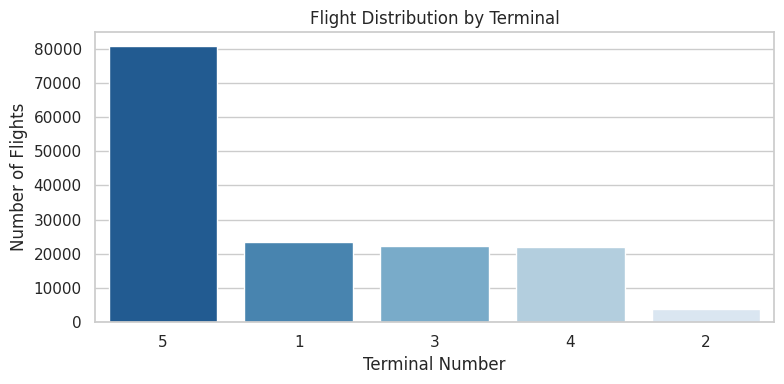

/tmp/ipykernel_357/1298186652.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_aircraft.values, y=top_aircraft.index, palette='crest')


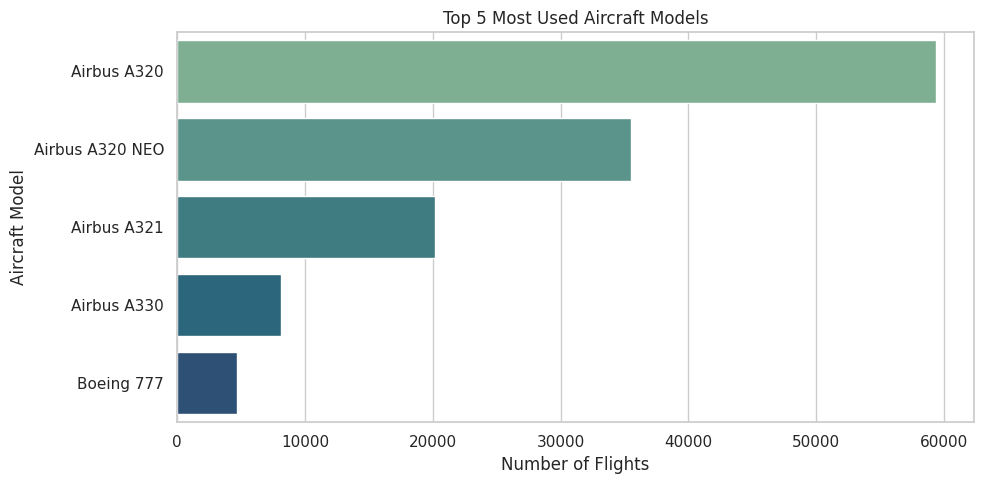

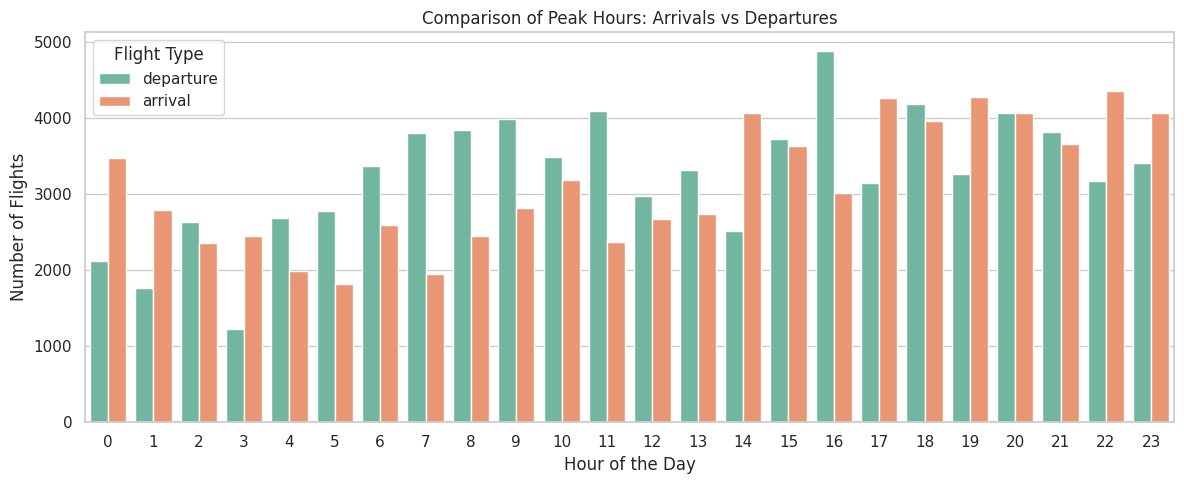

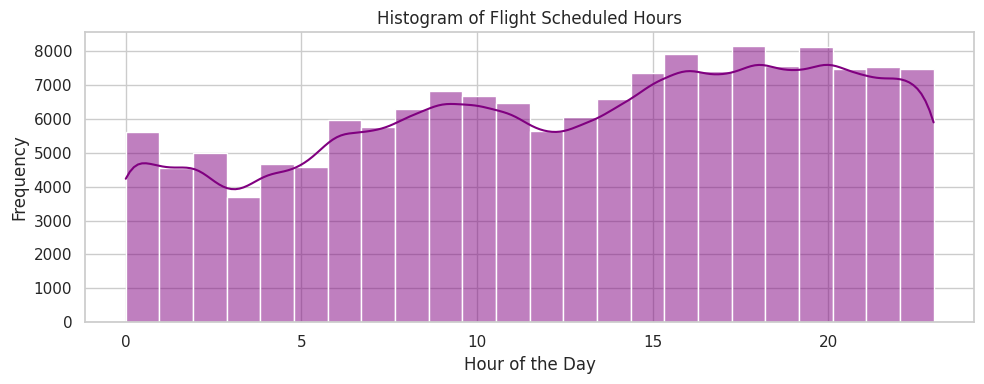

/tmp/ipykernel_357/1298186652.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=popular_terminals, x='terminal', y='hour', palette='Set3')


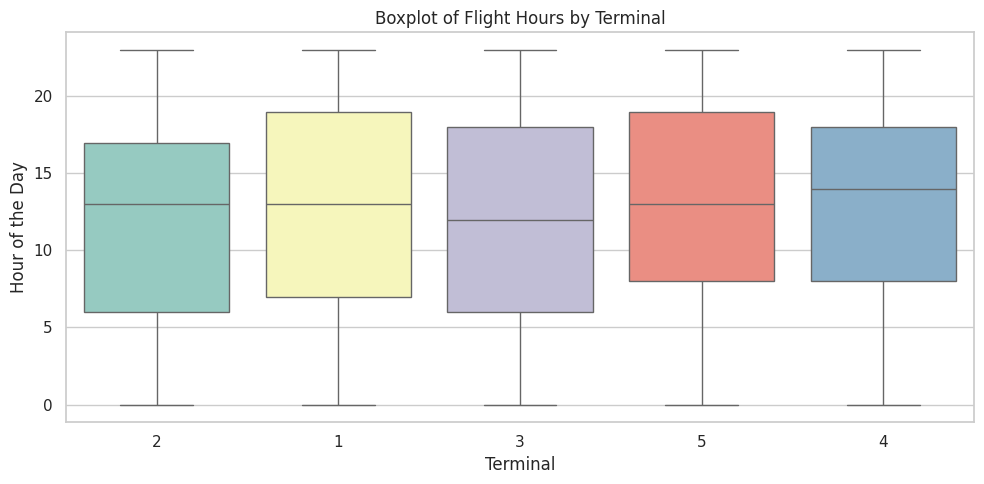

airline_name
Saudi Arabian    23
British          21
KLM               9
flyadeal          8
Air India         3
Name: count, dtype: int64


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/final_cleaned_flights_RUH.csv')

df['scheduled_time_local'] = pd.to_datetime(df['scheduled_time_local'])
df['hour'] = df['scheduled_time_local'].dt.hour

sns.set_theme(style="whitegrid")



terminal_counts = df[df['terminal'] != 'Unknown']['terminal'].value_counts()
plt.figure(figsize=(8, 4))
sns.barplot(x=terminal_counts.index, y=terminal_counts.values, palette='Blues_r')
plt.title('Flight Distribution by Terminal')
plt.xlabel('Terminal Number')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

top_aircraft = df[df['aircraft_model'] != 'Unknown']['aircraft_model'].value_counts().head(5)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_aircraft.values, y=top_aircraft.index, palette='crest')
plt.title('Top 5 Most Used Aircraft Models')
plt.xlabel('Number of Flights')
plt.ylabel('Aircraft Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='hour', hue='flight_type', palette='Set2')
plt.title('Comparison of Peak Hours: Arrivals vs Departures')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Flights')
plt.legend(title='Flight Type')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(df['hour'], bins=24, kde=True, color='purple')
plt.title('Histogram of Flight Scheduled Hours')
plt.xlabel('Hour of the Day')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

popular_terminals = df[df['terminal'].isin(['1', '2', '3', '4', '5'])]
plt.figure(figsize=(10, 5))
sns.boxplot(data=popular_terminals, x='terminal', y='hour', palette='Set3')
plt.title('Boxplot of Flight Hours by Terminal')
plt.xlabel('Terminal')
plt.ylabel('Hour of the Day')
plt.tight_layout()
plt.show()

canceled_flights = df[df['status'] == 'Canceled']
top_canceled_airlines = canceled_flights['airline_name'].value_counts().head(5)
print(top_canceled_airlines)


# Insights Summary
Patterns you discovered:
The analysis revealed clear "peak operational hours" where flight density spikes during specific times of the day. Additionally, a distinct pattern of workload distribution was discovered among the 5 terminals, showing that certain terminals bear a significantly higher volume of traffic than others.

 Interesting relationships:
There is a strong correlation between the flight type (commercial passenger vs. others) and its daily schedule, which directly impacts the operational density across different terminals throughout the 24-hour cycle.
 Any outliers:

A few specific airlines stood out as outliers due to their exceptionally high frequency of flight cancellations compared to the rest of the dataset, highlighting areas of potential operational instability.
 Key takeaways:

The project delivers data-driven insights that can help airport management optimize staffing, ground resource allocation, and terminal gate planning during peak hours, while providing a solid KPI metric to evaluate airline reliability.